In [131]:
import scanpy as sc
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt
#import matplotlib as mpl
import muon as mu
import anndata as ad
from scipy.io import mmread

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
# --- Configuration ---
RNA_COUNTS_FILE = "../data/mouse_brain_data/GSM4156610_brain.rna.counts.txt.gz"
ATAC_COUNTS_FILE = "../data/mouse_brain_data/GSM4156599_brain.counts.txt.gz" # Matrix Market sparse file
ATAC_PEAKS_FILE = "../data/mouse_brain_data/GSM4156599_brain.peaks.bed.gz" # Peaks BED file
CELLTYPE_FILE = "../data/mouse_brain_data/GSM4156599_brain_celltype.txt.gz" # Contains paired barcodes and cell types
ATAC_BARCODES_FILE = "../data/mouse_brain_data/GSM4156599_brain.barcodes.txt.gz" # This file *should* contain barcodes corresponding to the Matrix columns

## scRNA

In [4]:
# Load the cell type/pairing file
# This file links ATAC and RNA barcodes for the paired cells (3293 cells)

df_celltype = pd.read_csv(CELLTYPE_FILE, sep='\t')

In [5]:
df_celltype = df_celltype.set_index('rna.bc')

In [6]:
# Get the list of paired RNA barcodes to use as common cell IDs

common_cell_ids = df_celltype.index.tolist()

In [7]:
# Load RNA counts matrix (Genes x Cells)

df_rna_counts = pd.read_csv(RNA_COUNTS_FILE, sep='\t', index_col=0)

In [8]:
# Clean the column names (cell barcodes) in the RNA counts DataFrame
# They use commas (,) but the celltype file uses periods (.)
# Replace commas with periods to match the common_cell_ids format

df_rna_counts.columns = df_rna_counts.columns.str.replace(',', '.', regex=False)

In [9]:
# Subset the RNA counts DataFrame to keep only the columns (cells) that are in our paired set
# This aligns the RNA data to the 3293 paired cells
# .reindex(columns=...) will select the columns and also handle cases where a barcode might be missing (inserts NaNs)
# We use .dropna(axis=1) to remove any columns that were entirely NaN if reindexing failed
df_rna_subset = df_rna_counts.reindex(columns=common_cell_ids).dropna(axis=1)

In [12]:
# Verify that the columns now exactly match the common cell IDs
if list(df_rna_subset.columns) != common_cell_ids:
     print("Error: Subsetting RNA counts failed to exactly match common cell IDs!")
     # Handle error - critical for alignment
else:
     print("RNA counts columns successfully subsetted and aligned to common cell IDs.")

RNA counts columns successfully subsetted and aligned to common cell IDs.


In [15]:
# Transpose the DataFrame to be Cells x Genes for AnnData
df_rna_transposed = df_rna_subset.T.copy() # Use .T for transpose and .copy()

In [16]:
# Create the AnnData object for RNA
# X: The transposed counts matrix (Paired_Cells x Genes)
# obs: Observation metadata (cells). Index should be the common cell IDs.
# var: Variable metadata (genes). Index should be the gene IDs.
adata_rna = ad.AnnData(
    X=df_rna_transposed,
    obs=pd.DataFrame(index=df_rna_transposed.index), # Use transposed index (common cell IDs) for obs names
    var=pd.DataFrame(index=df_rna_transposed.columns) # Use transposed columns (gene IDs) for var names
)

In [31]:
# Add cell type annotations to adata_rna.obs
# The index of adata_rna.obs is common_cell_ids (rna.bc)
# The index of df_celltype is also rna.bc
# Merge df_celltype (keeping only the 'celltype' column) into adata_rna.obs
adata_rna.obs = adata_rna.obs.merge(df_celltype[['celltype']], left_index=True, right_index=True, how='left')

## QC for RNA

Check for mitochondrial genes

In [43]:
adata_rna.var_names.str.startswith("Mt-").sum()

0

In [44]:
sc.pp.calculate_qc_metrics(
    adata_rna, inplace=True, log1p=True
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


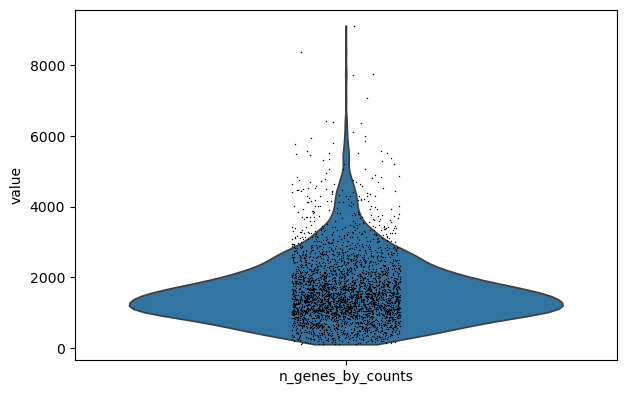

In [56]:
sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


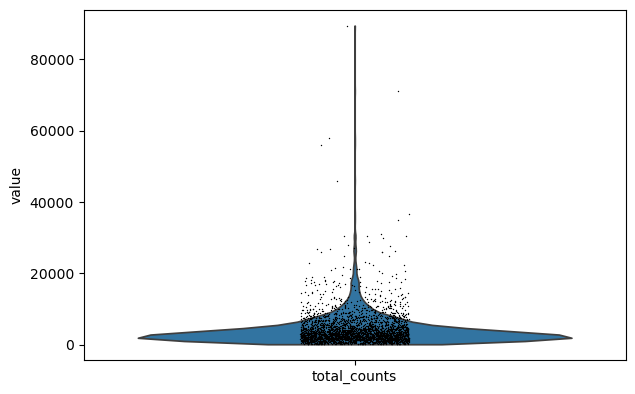

In [53]:
sc.pl.violin(
    adata_rna,
    ["total_counts"]
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


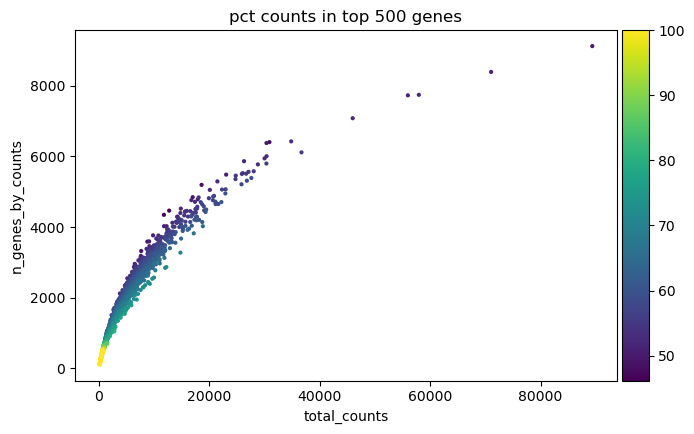

In [61]:
sc.pl.scatter(adata_rna, "total_counts", "n_genes_by_counts", color="pct_counts_in_top_500_genes")

In [92]:
sc.pp.filter_cells(adata_rna, min_genes=100)

In [94]:
sc.pp.filter_genes(adata_rna, min_cells=2)

In [96]:
#sc.pp.scrublet(adata_rna, copy=True)

## Normalization

In [101]:
# Saving count data
adata_rna.layers["counts"] = adata_rna.X.copy()

In [102]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_rna)
# Logarithmize the data
sc.pp.log1p(adata_rna)

## Feature Selection

In [106]:
sc.pp.highly_variable_genes(adata_rna, n_top_genes=2000)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


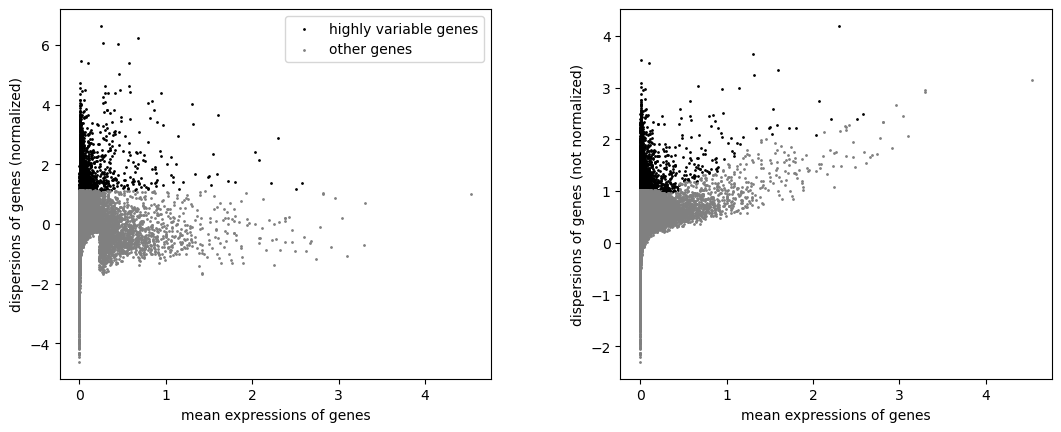

In [109]:
sc.pl.highly_variable_genes(adata_rna)

## Dimensionality Reduction

In [110]:
sc.tl.pca(adata_rna)

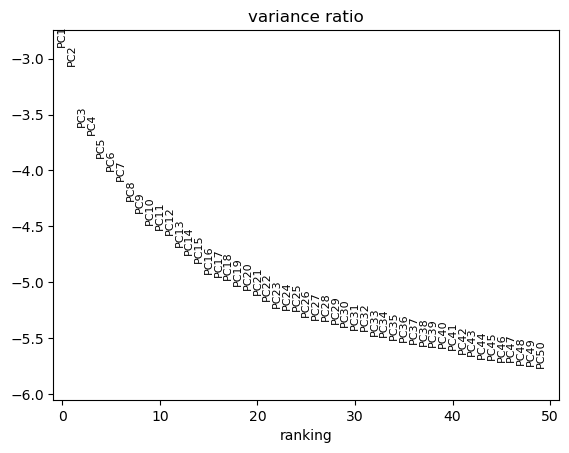

In [111]:
sc.pl.pca_variance_ratio(adata_rna, n_pcs=50, log=True)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


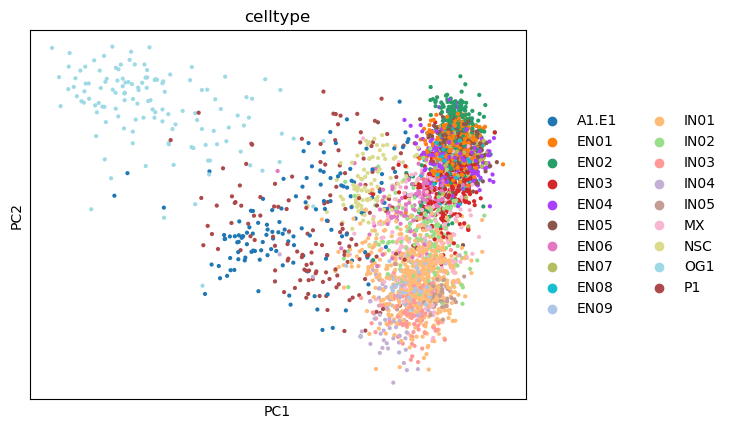

In [116]:
sc.pl.pca(
    adata_rna, color="celltype"
)

## scATAC

In [119]:
atac = sc.read_mtx("../data/mouse_brain_data/GSM4156599_brain.counts.txt.gz").T

In [133]:
atac_matrix_sparse = mmread(ATAC_COUNTS_FILE)

In [150]:
# BED format (chr, start, end), tab-separated, no header
# Create peak IDs like "chr_start_end"
df_peaks = pd.read_csv(ATAC_PEAKS_FILE, sep='\t', header=None, usecols=[0,1,2])
df_peaks['peak_id'] = df_peaks[0].astype(str) + '_' + df_peaks[1].astype(str) + '_' + df_peaks[2].astype(str)
peak_names = df_peaks['peak_id'].tolist()
print(f"Loaded {len(peak_names)} peak names.")

Loaded 428041 peak names.


In [202]:
# Create the AnnData object for the ATAC modality
# X: Transpose the sparse matrix to be Cells x Peaks for AnnData (from Peaks x Cells in Matrix Market)

adata_atac = ad.AnnData(
    X=atac_matrix_sparse.T, # Transpose to Cells x Peaks
    obs=pd.DataFrame(index=common_cell_ids), # Use common RNA barcodes (rna.bc) as obs names for alignment
    var=pd.DataFrame(index=peak_names) # Use peak IDs as var names
)

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


In [187]:
# Basic ATAC specific preprocessing (binarization)
# Convert counts (>0) to binary (1) representing presence of accessibility

adata_atac.X = (adata_atac.X > 0).astype(float) # Convert sparse matrix values to 0 or 1

Performing ATAC binarization.
ATAC binarization complete.


In [204]:
non_zero_elements = atac_matrix_sparse.nnz
print(f"Number of non-zero elements: {non_zero_elements}")
# This should print 3501137

Number of non-zero elements: 3501137


In [169]:
mdata = mu.MuData({'rna': adata_rna, 'atac': adata_atac})

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [177]:
mu.atac.tl.initialise_default_files(adata_atac, path="../data/mouse_brain_data/")

In [181]:
mu.atac.tl.locate_file(adata_atac, key="fragments", file="../data/mouse_brain_data/GSM4156599_brain.atac.fragments.bed.gz")

In [184]:
mu.atac.tl.locate_fragments(adata_atac, fragments="../data/mouse_brain_data/GSM4156599_brain.atac.fragments.bed.gz")

index `../data/mouse_brain_data/GSM4156599_brain.atac.fragments.bed.gz.tbi` not found


In [185]:
mu.atac.tl.tss_enrichment(adata_atac)

ValueError: Argument `features` is required. It should be a BED-like DataFrame with gene coordinates and names.

In [208]:
mu.atac.tl.locate_fragments(adata_atac, fragments='/nfs/home/students/l.reich/tangram/data/mouse_brain_data/sorted.bed.gz')

In [209]:
adata_atac

AnnData object with n_obs × n_vars = 3293 × 428041
    uns: 'files'